In [21]:
import pandas as pd
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
            'marital-status', 'occupation', 'relationship', 'race', 'sex', 
            'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
data = pd.read_csv('../dataset/adult/train.csv', names=columns, skipinitialspace=True, na_values='?')
data['sex']=data['sex'].map({'Male': 0, 'Female': 1})

Statistically analyze the male - female ratio of "sex" in sensitive attributes

In [22]:
sex = data['sex'].value_counts()
sex

sex
0    21790
1    10771
Name: count, dtype: int64

Statistically analyze the age distribution

In [23]:
age = data['age'].value_counts()
age

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, log_loss
from fairlearn.metrics import MetricFrame, equalized_odds_difference
import matplotlib.pyplot as plt
from scipy.stats import expon
import random
import os
import math

from fairlearn.metrics import (
    MetricFrame,
    count,
    false_negative_rate,
    false_positive_rate,
    selection_rate,
)

class AdultClient:
    def __init__(self, client_id, epsilon=0.1, bin_size=1, sensitive_attribute='sex', is_fair=True, exf=0.1):
        """Initialize the client"""
        self.client_id = client_id
        self.epsilon = epsilon  # Privacy budget
        self.bin_size = bin_size  # The size of the sensitive attribute range
        self.is_fair = is_fair  # Whether to use fairness constraints
        self.exf = exf
        self.model = None
        self.original_data = None
        self.protected_data = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.sensitive_attribute = sensitive_attribute  # sensitive attributes
        self.writer = None
        self.preprocessor = None
        
    def load_data(self):
        """Load the Adult dataset and split it for clients"""
        # Load the complete Adult dataset
        columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
                   'marital-status', 'occupation', 'relationship', 'race', 'sex', 
                   'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
        data = pd.read_csv('../dataset/adult/train.csv', names=columns, skipinitialspace=True, na_values='?')
        data['sex']=data['sex'].map({'Male': 0, 'Female': 1})
    
        data = data.dropna()
        
        n = len(data)
        if self.client_id == 0:
            self.original_data = data.iloc[:n//3]
        elif self.client_id == 1:
            self.original_data = data.iloc[n//3:2*n//3]
        else:
            self.original_data = data.iloc[2*n//3:]
        
        print(f"Client {self.client_id} load {len(self.original_data)} piece of data")
        
        return self.original_data
    
    def create_age_candidates(self, data): 
        """
        Construct the discrete output candidate set A: age intervals, corresponding to the output space S in the definition (here S = A)
        Return: list of candidate intervals (e.g., [(18, 22), (23, 27), ...]), size of the candidate set |A|
        """
        min_sen = data[self.sensitive_attribute].min()
        max_sen = data[self.sensitive_attribute].max()
        # Construct equal-width intervals to ensure coverage of all ages
        bins = []
        current = min_sen
        while current < max_sen:
            bins.append((current, current + self.bin_size))
            current += self.bin_size
        # Handle the situation where the last interval may exceed max_sen (optional: truncate or complete)
        bins[-1] = (bins[-1][0], max_sen) if bins[-1][1] > max_sen else bins[-1]
        return bins, len(bins)  
    
    def exponential_mechanism(self, data, bins, A_size):  
        """
        Construct the exponential mechanism strictly according to the definition:
        - Input a: The original age of the current sample (or the dataset, which needs to be aligned with the defined scenario)
        - Output s: The candidate interval, which belongs to bins
        Here it is simplified to: For a single sample, the input a is its original age, and the output s is the candidate interval
        """
        # Define "input a" as the original age of the sample (needs to be adjusted according to the scenario. If a is a dataset, it needs to be re - adapted).
        a = data[self.sensitive_attribute].values[0] if not data.empty else None

        # Calculate probability: According to the definition formula in the paper
        # π: The probability when s = a (Here, a needs to be mapped to the corresponding interval. Simplified as: If the interval contains a, then s = a corresponds to that interval)
        probabilities = []

        for interval in bins:
            # Determine whether the interval contains the original age a (simplified logic, needs to be strictly aligned according to the definition)
            
            if interval[0] <= a < interval[1]:
                # Case where s = a: Probability π
                prob = math.exp(self.epsilon) / (A_size - 1 + math.exp(self.epsilon))  
            else:
                # Case where s ≠ a: Probability π̄
                prob = 1 / (A_size - 1 + math.exp(self.epsilon))  
            probabilities.append(prob)
        
        # Normalization (theoretically, the formula ensures the sum is 1, but in actual floating - point operations, it may need to be corrected)
        probabilities = np.array(probabilities) / np.sum(probabilities)
        return probabilities
    
    def apply_exponential_mechanism_to_dataset(self):
        """
        Apply the improved exponential mechanism: for each sample, select the output from the candidate intervals, which strictly conforms to the definition.
        """
        if self.original_data is None:
            self.load_data()
        
        # Construct candidate set
        bins, A_size = self.create_age_candidates(self.original_data)  
        self.protected_data = self.original_data.copy()
        
        for i, row in self.original_data.iterrows():
            sample_data = pd.DataFrame([row])
            # Calculate the probability of candidate intervals
            probs = self.exponential_mechanism(sample_data, bins, A_size)  
            # Select intervals according to probability
            selected_idx = np.random.choice(len(bins), p=probs)
            selected_interval = bins[selected_idx]
            # Use the midpoint of the interval as the protected age (or use the interval directly, adjust as needed)
            protected_sen = (selected_interval[0] + selected_interval[1] - 1) / 2
            self.protected_data.at[i, self.sensitive_attribute] = protected_sen
            # print(f"protected_sen:{protected_sen}")
        
        print(f"Client {self.client_id} Apply the exponential mechanism that conforms to the definition to protect age privacy")
        return self.protected_data
    
    def preprocess_data(self, data):
        """Preprocess the data and prepare for training"""
        # Copy the data to avoid modifying the original data.
        processed_data = data.copy()
        
        # Separate feature and target variables
        X = processed_data.drop('income', axis=1)
        y = processed_data['income']
        
        # Convert the target variable to binary
        y = y.map({'<=50K': 0, '>50K': 1})
        
        # Identify numerical features and categorical features
        numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
        categorical_features = X.select_dtypes(include=['object']).columns
        
        # Create a preprocessing pipeline
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
            ])
        
        # Split the data into training set and test set
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Preprocess data
        X_train_processed = self.preprocessor.fit_transform(X_train)
        X_test_processed = self.preprocessor.transform(X_test)
        
        # Save the preprocessed data
        self.X_train = X_train_processed
        self.y_train = y_train
        self.X_test = X_test_processed
        self.y_test = y_test
        
        # Save sensitive attribute data
        self.sensitive_train = X_train[self.sensitive_attribute].to_numpy()
        self.sensitive_test = X_test[self.sensitive_attribute].to_numpy()
        
        return X_train_processed, y_train, X_test_processed, y_test
    
    def train_base_model(self):
        """Train the basic model"""
        if self.protected_data is None:
            self.apply_exponential_mechanism_to_dataset()
        
        # Preprocess data
        self.preprocess_data(self.protected_data)
        
        # Create and train the model
        self.model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
        self.model.fit(self.X_train, self.y_train)
        
        # Evaluate the model
        y_pred = self.model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        
        print(f"Client {self.client_id} base model accuracy: {accuracy:.4f}")
        
        return self.model
    
    def train_fair_model(self):
        """Train a fairness model"""
        if self.protected_data is None:
            self.apply_exponential_mechanism_to_dataset()
        
        # Preprocess data
        self.preprocess_data(self.protected_data)
        
        # Train a fair model using the ExponentiatedGradient algorithm of fairlearn
        from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds, GridSearch
        
        # Create fairness constraints
        constraint = EqualizedOdds()
        
        # Create a basic model
        base_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=100)
        
        # Train a fair model using Exponentiated Gradient
        fair_model = ExponentiatedGradient(base_model, constraint, eps=self.exf)
        # fair_model = GridSearch(base_model, constraint)
        fair_model.fit(self.X_train, self.y_train, sensitive_features=self.sensitive_train)
        
        # Evaluate the model
        y_pred = fair_model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        loss = log_loss(self.y_test, y_pred)
        
        # Calculate fairness metrics
        metric_frame = MetricFrame(
            metrics={
                'accuracy': accuracy_score,
                'selection_rate': selection_rate,
                'false_positive_rate': false_positive_rate,
                'false_negative_rate': false_negative_rate,
            },
            y_true=self.y_test,
            y_pred=y_pred,
            sensitive_features=self.sensitive_test
        )
        
        # Calculate the Discrimination
        # eq_odds_diff = equalized_odds_difference(
        #     self.y_test, y_pred, sensitive_features=self.sensitive_test
        # )
        eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
        
        print(f"Client {self.client_id} Fair model accuracy: {accuracy:.4f}")
        print(f"Client {self.client_id} Fair model loss: {loss:.4f}")
        print(f"Client {self.client_id} Discrimination: {eq_odds_diff:.4f}")
        
        self.model = fair_model
        
        return self.model, accuracy, loss, eq_odds_diff
    
    def train(self):
        """Train the model (select different training methods depending on whether fairness is enabled)"""
        if self.is_fair:
            return self.train_fair_model()
        else:
            model = self.train_base_model()
            y_pred = model.predict(self.X_test)
            accuracy = accuracy_score(self.y_test, y_pred)
            loss = log_loss(self.y_test, y_pred)
            eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
            return model, accuracy, loss, eq_odds_diff
    
    def evaluate(self, model=None):
        """Evaluate model performance"""
        if model is None:
            model = self.model
        
        if model is None:
            print("The model has not been trained")
            return None
        
        # predict
        y_pred = model.predict(self.X_test)
        
        # Calculate accuracy
        accuracy = accuracy_score(self.y_test, y_pred)
        loss = log_loss(self.y_test, y_pred)
        
        # If fairness is enabled, calculate the fairness metrics.
        if self.is_fair:
            # eq_odds_diff = equalized_odds_difference(
            #     self.y_test, y_pred, sensitive_features=self.sensitive_test
            # )
            eq_odds_diff = max(measure_EO(self.y_test, self.sensitive_test, y_pred, 0),measure_EO(self.y_test, self.sensitive_test, y_pred, 1))
            return accuracy, loss, eq_odds_diff
        else:
            return accuracy, loss

def measure_EO(Y, A, Yhat, y_value):
    """
    Calculate the Equal Opportunity indicator, cite the paper "Fair Learning with Private Demographic Data"

    Parameters:
    Y: List or Series of true labels
    A: List or Series of sensitive attributes (such as gender, race, etc.)
    Yhat: List or Series of predicted probabilities
    y_value: The true label value to be evaluated

    Returns:
    EO_violation: The degree of equal opportunity violation (maximum group difference)
    """
    
    # Handle possible Pandas Series input
    if isinstance(Y, pd.Series):
        Y = Y.values
    if isinstance(A, pd.Series):
        A = A.values
    if isinstance(Yhat, pd.Series):
        Yhat = Yhat.values
    
    # Get the set of unique values of sensitive attributes
    unique_groups = set(A)
    # Ensure that the group labels are consecutive integers starting from 0
    group_mapping = {group: i for i, group in enumerate(unique_groups)}
    classes = len(unique_groups)
    
    # Initialize statistics
    Yhats = [0] * classes
    conditionals = [0] * classes
    
    # Ensure that the length of the input data is consistent
    if len(Y) != len(A) or len(Y) != len(Yhat):
        raise ValueError("The lengths of the input lists Y, A, and Yhat must be the same.")
    
    # Calculate the sum of prediction probabilities for each group under the given true labels
    for i in range(len(Y)):
        if Y[i] == y_value:
            # Use the mapped group index
            group_idx = group_mapping[A[i]]
            Yhats[group_idx] += Yhat[i]
            conditionals[group_idx] += 1
    
    # Calculate the conditional expectation for each group
    expectations = [0] * classes
    for i in range(classes):
        if conditionals[i] > 0:
            expectations[i] = Yhats[i] / conditionals[i]
    
    # Calculate the differences between groups
    EO_diff = []
    for i in range(classes):
        for j in range(i+1, classes):
            EO_diff.append(abs(expectations[i] - expectations[j]))
    
    # Return the maximum difference as the degree of equal opportunity violation
    EO_violation = max(EO_diff) if EO_diff else 0
    return EO_violation

def federated_aggregation(clients):
    """Federated learning model aggregation"""
    # Extract the model coefficients and intercepts of all clients
    coefs = []
    intercepts = []
    
    for client in clients:
        if hasattr(client.model, 'predictors_'):
            # If it is the ExponentiatedGradient model of fairlearn
            client_coefs = np.array([p.coef_[0] for p in client.model.predictors_])
            client_intercepts = np.array([p.intercept_[0] for p in client.model.predictors_])
            
            # Use the weighted average model
            # weights = client.model.weights_
            weights = np.array(client.model.weights_)
            weighted_coef = np.sum(client_coefs * weights[:, np.newaxis], axis=0)
            weighted_intercept = np.sum(client_intercepts * weights)
            
            coefs.append(weighted_coef)
            intercepts.append(weighted_intercept)
        else:
            # Base model
            coefs.append(client.model.coef_[0])
            intercepts.append(client.model.intercept_[0])
    
    # Ensure that the shapes of all coefficients are consistent
    print(f"Coefficient shape check: {[c.shape for c in coefs]}")
    
    # Handle possible shape inconsistency issues
    if any(c.shape != coefs[0].shape for c in coefs):
        # print("Warning: Inconsistent coefficient shapes detected. Attempting to adjust...")
        
        # Get the maximum dimension
        max_dim = max(c.shape[0] for c in coefs)
        
        # Adjust all coefficients to the maximum dimension
        adjusted_coefs = []
        for c in coefs:
            if c.shape[0] < max_dim:
                # Pad zeros to the maximum dimension
                adjusted_c = np.zeros(max_dim)
                adjusted_c[:c.shape[0]] = c
                adjusted_coefs.append(adjusted_c)
            else:
                adjusted_coefs.append(c)
        
        coefs = adjusted_coefs
    
    # Average coefficient and intercept
    avg_coef = np.mean(coefs, axis=0)
    avg_intercept = np.mean(intercepts)
    
    # Create a new model and set parameters
    aggregated_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    
    # Use the preprocessor of the first client
    first_client = clients[0]
    
    # Create a complete dataset (combining data from all clients)
    all_data = pd.concat([client.original_data for client in clients])
    
    # Use the preprocessor of the first client to process the merged data
    X_all = all_data.drop('income', axis=1)
    y_all = all_data['income'].map({'<=50K': 0, '>50K': 1})
    
    # Preprocess data
    X_all_processed = first_client.preprocessor.transform(X_all)
    
    # Split the data into training set and test set
    X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
        X_all_processed, y_all, test_size=0.2, random_state=42
    )
    
    # Train the model using the merged dataset
    aggregated_model.fit(X_train_all, y_train_all)
    
    # Ensure that the coefficient dimensions match
    if avg_coef.shape != aggregated_model.coef_[0].shape:
        # print(f"Warning: Dimension of aggregation coefficient {avg_coef.shape} With the expected dimensions of the model {aggregated_model.coef_[0].shape} Not match")
        # print("Try to adjust the dimension of the coefficient...")
        
        # Adjust the coefficient dimension
        if avg_coef.shape[0] > aggregated_model.coef_[0].shape[0]:
            avg_coef = avg_coef[:aggregated_model.coef_[0].shape[0]]
        else:
            new_coef = np.zeros_like(aggregated_model.coef_[0])
            new_coef[:avg_coef.shape[0]] = avg_coef
            avg_coef = new_coef
    
    # Set coefficients and intercepts
    aggregated_model.coef_[0] = avg_coef
    aggregated_model.intercept_[0] = avg_intercept
    
    # save the first preprocessor
    aggregated_model.preprocessor = first_client.preprocessor
    
    return aggregated_model


def run_federated_learning(num_clients=3, num_rounds=5, epsilon=0.1, bin_size=1, sensitive_attribute='sex', is_fair=True, exf=0.1):
    """Run the FL training process"""
    clients = []
    for i in range(num_clients):
        client = AdultClient(client_id=i, epsilon=epsilon, bin_size=bin_size, sensitive_attribute=sensitive_attribute, is_fair=is_fair, exf=exf)
        clients.append(client)
    
    # Record the metrices in each round
    global_accuracies = []
    global_losses = []
    global_eq_odds_diffs = []
    
    # The training process of federated learning
    for round in range(num_rounds):
        print(f"\n===== Federated learning rounds {round+1}/{num_rounds} =====")
        
        # Local training
        local_models = []
        local_accuracies = []
        local_losses = []
        local_eq_odds_diffs = []
        
        for client in clients:
            print(f"\n Client {client.client_id} local training in progress...")
            model, accuracy, loss, eq_odds_diff = client.train()
            local_models.append(model)
            local_accuracies.append(accuracy)
            local_losses.append(loss)
            if eq_odds_diff is not None:
                local_eq_odds_diffs.append(eq_odds_diff)
        
        # Print local training results
        # print("\n Local training results:")
        # for i, (acc, lo, eq_odds) in enumerate(zip(local_accuracies, local_losses, local_eq_odds_diffs)):
        #     print(f"Client {i}: Accuracy = {acc:.4f}, Loss = {lo:.4f}, Discrimination = {eq_odds:.4f}")
        
        # Model Aggregation
        print("\nModel aggregation in progress...")
        global_model = federated_aggregation(clients)
        
        # Evaluate the global model
        global_accuracy = 0
        global_loss = 0
        global_eq_odds_diff = 0
        
        for client in clients:
            print(f"Evaluation client {client.client_id} of the model...")
            
            # Use the preprocessor of the global model to process client data
            X_client = client.original_data.drop('income', axis=1)
            y_client = client.original_data['income'].map({'<=50K': 0, '>50K': 1})
            
            # Split client data into training set and test set
            X_client_train, X_client_test, y_client_train, y_client_test = train_test_split(
                X_client, y_client, test_size=0.2, random_state=42
            )
            
            # Use the pre - processor of the global model to process the client test data
            X_client_test_processed = global_model.preprocessor.transform(X_client_test)
            
            # Use the global model for prediction
            y_pred = global_model.predict(X_client_test_processed)
            # Calculate accuracy
            accuracy = accuracy_score(y_client_test, y_pred)
            loss = log_loss(y_client_test, y_pred)
            print(f"global server accuracy:------------{accuracy}")
            print(f"global server loss:------------{loss}")
            
            # If fairness is enabled, calculate the fairness metrics.
            
            sensitive_client_test = X_client_test[client.sensitive_attribute]
            # eq_odds_diff = equalized_odds_difference(
            #     y_client_test, y_pred, sensitive_features=sensitive_client_test
            # )
            eq_odds_diff = max(measure_EO(y_client_test, sensitive_client_test, y_pred, 0),measure_EO(y_client_test, sensitive_client_test, y_pred, 1))
            
            print(f"Accuracy: {accuracy:.4f}, loss: {loss:.4f}, Discrimination: {eq_odds_diff:.4f}")
            global_accuracy += accuracy
            global_loss += loss
            global_eq_odds_diff += eq_odds_diff

        
        global_accuracy /= num_clients
        global_loss /= num_clients
        global_eq_odds_diff /= num_clients
        print(f"\nGlobal model performance: Accuracy = {global_accuracy:.4f}, Loss = {global_loss:.4f}, Discrimination = {global_eq_odds_diff:.4f}")
      
        
        # Save the results of this round
        global_accuracies.append(global_accuracy)
        global_losses.append(global_loss)
        global_eq_odds_diffs.append(global_eq_odds_diff)
        
        # Distribute the global model to each client
        for client in clients:
            client.model = global_model
    
    # Return the final model and performance metrics
    return global_model, global_accuracies, global_losses, global_eq_odds_diffs


# """Analyze the privacy-fairness-utility trade-off"""
# epsilons = [0.01, 0.1, 1.0, 10]
eps = [-2, -1, 0, 1, 2] # log(epsilon)
sensitive_attribute = 'age' # 
results = {}

for ep in eps:
    epsilon = 10**ep
    print(f"\n===== Privacy budget = {epsilon} =====")
    
    # Without fairness
    print("\n--- Without fairness ---")
    _, accuracies_no_fair, losses_no_fair, eq_odds_diffs_no_fair = run_federated_learning(
        num_clients=3, 
        num_rounds=2, 
        epsilon=epsilon, 
        is_fair=False,
        bin_size=2,
        sensitive_attribute = sensitive_attribute,
        exf=0.1
    )
    
    # With fairness
    print("\n--- With fairness ---")
    _, accuracies_fair, losses_fair, eq_odds_diffs_fair = run_federated_learning(
        num_clients=3, 
        num_rounds=2, 
        epsilon=epsilon, 
        is_fair=True,
        bin_size=2,
        sensitive_attribute=sensitive_attribute,
        exf=0.1
    )
    results[ep] = {
        'no_fair': {
            'accuracy': accuracies_no_fair[-1],
            'loss': losses_no_fair[-1],
            'eq_odds_diff': eq_odds_diffs_no_fair[-1]
            },
        'fair': {
            'accuracy': accuracies_fair[-1],
            'loss': losses_fair[-1],
            'eq_odds_diff': eq_odds_diffs_fair[-1]}
    }


===== Privacy budget = 0.01 =====

--- Without fairness ---

===== Federated learning rounds 1/2 =====

 Client 0 local training in progress...
Client 0 load 10054 piece of data


/tmp/ipykernel_4049168/3190030875.py:132: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '39.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, self.sensitive_attribute] = protected_sen


Client 0 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 0 base model accuracy: 0.8543

 Client 1 local training in progress...
Client 1 load 10054 piece of data


/tmp/ipykernel_4049168/3190030875.py:132: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '31.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, self.sensitive_attribute] = protected_sen


Client 1 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 1 base model accuracy: 0.8369

 Client 2 local training in progress...
Client 2 load 10054 piece of data


...

Client 0 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 0 Fair model accuracy: 0.7598
Client 0 Fair model loss: 8.6569
Client 0 Discrimination: 1.0000

 Client 1 local training in progress...
Client 1 load 10054 piece of data


/tmp/ipykernel_4049168/3190030875.py:132: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '51.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, self.sensitive_attribute] = protected_sen


Client 1 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 1 Fair model accuracy: 0.7374
Client 1 Fair model loss: 9.4635
Client 1 Discrimination: 1.0000

 Client 2 local training in progress...
Client 2 load 10054 piece of data


/tmp/ipykernel_4049168/3190030875.py:132: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '57.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.protected_data.at[i, self.sensitive_attribute] = protected_sen


Client 2 Apply the exponential mechanism that conforms to the definition to protect age privacy
Client 2 Fair model accuracy: 0.7474
Client 2 Fair model loss: 9.1050
Client 2 Discrimination: 1.0000

Model aggregation in progress...
Coefficient shape check: [(101,), (103,), (102,)]
Evaluation client 0 of the model...
global server accuracy:------------0.7667826951765291
global server loss:------------8.406003699401266
Accuracy: 0.7668, loss: 8.4060, Discrimination: 0.0833
Evaluation client 1 of the model...
global server accuracy:------------0.7354549975136748
global server loss:------------9.53516837544024
Accuracy: 0.7355, loss: 9.5352, Discrimination: 0.1000
Evaluation client 2 of the model...
global server accuracy:------------0.7389358528095475
global server loss:------------9.409705633658133
Accuracy: 0.7389, loss: 9.4097, Discrimination: 0.0625

Global model performance: Accuracy = 0.7471, Loss = 9.1170, Discrimination = 0.0819

===== Federated learning rounds 2/2 =====

 Client 

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4049168/2971733189.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
/tmp/ipykernel_4049168/2971733189.py:40: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
/tmp/ipykernel_4049168/2971733189.py:59: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)


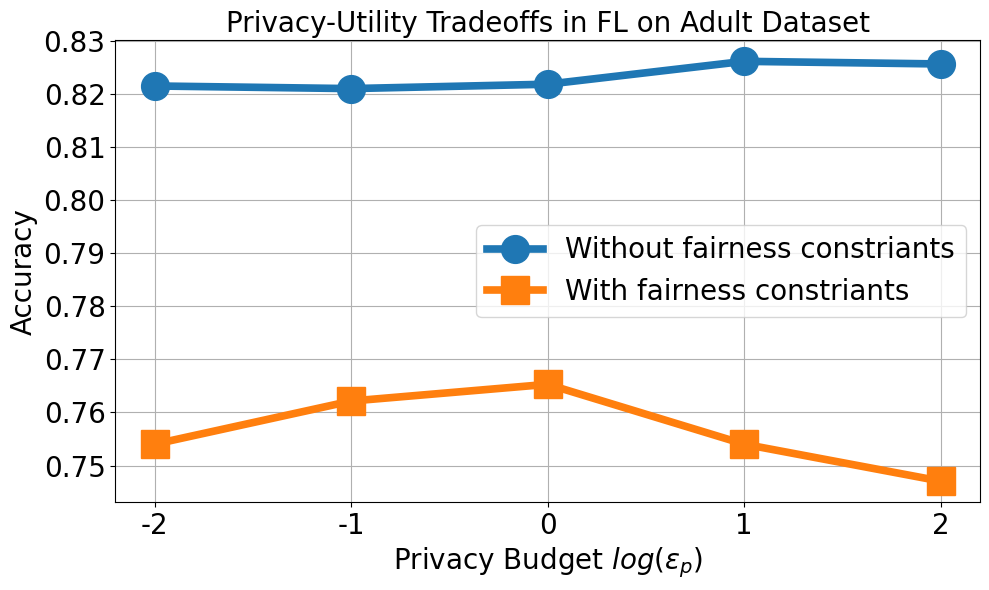

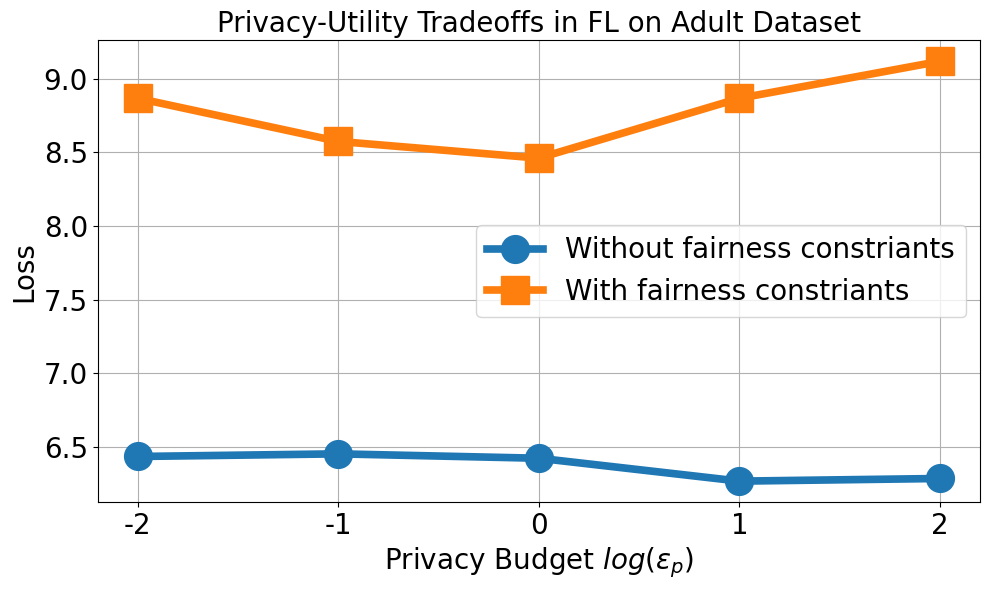

[1.0, 1.0, 1.0, 1.0, 1.0]
[0.5666666666666667, 0.5952380952380952, 0.6666666666666666, 0.5666666666666667, 0.08194444444444444]


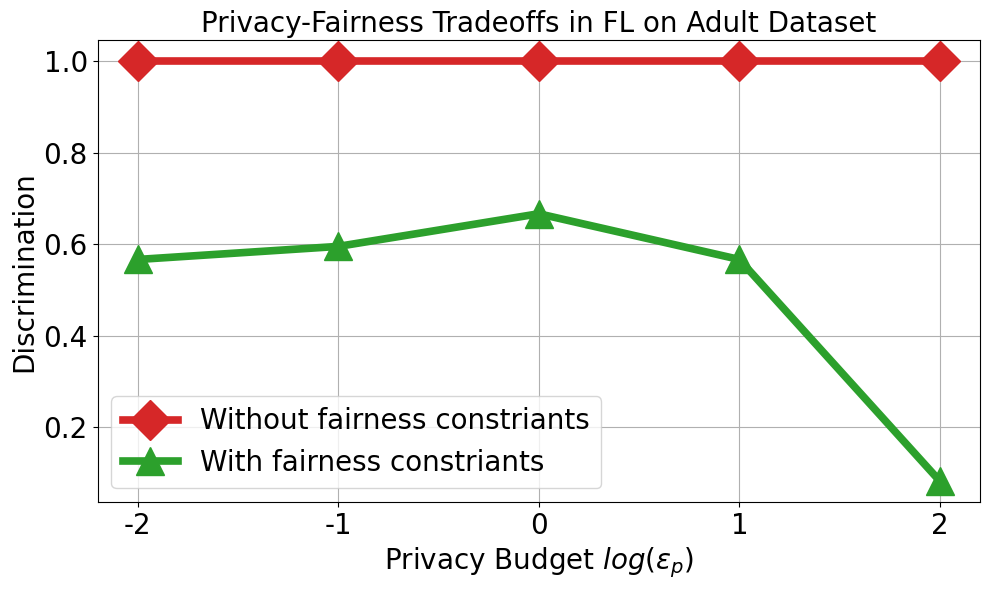

In [8]:
def plot_tradeoff(results):
    """Draw the privacy-fairness-utility tradeoffs chart in FL on Adult Dataset"""
    epsilons = list(results.keys())
    no_fair_accuracies = [results[eps]['no_fair']['accuracy'] for eps in epsilons]
    fair_accuracies = [results[eps]['fair']['accuracy'] for eps in epsilons]
    no_fair_losses = [results[eps]['no_fair']['loss'] for eps in epsilons]
    fair_losses = [results[eps]['fair']['loss'] for eps in epsilons]
    no_eq_odds_diffs = [results[eps]['no_fair']['eq_odds_diff'] for eps in epsilons]
    eq_odds_diffs = [results[eps]['fair']['eq_odds_diff'] for eps in epsilons]

    x_positions = np.arange(len(epsilons))
    
    # accuracy
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    plt.figure(figsize=(10,6))
    
    # Draw accuracy comparison
    plt.plot(x_positions, no_fair_accuracies, color='#1f77b4', linestyle='-', label='Without fairness constriants', marker='o',linewidth=5.5, markersize=20)
    plt.plot(x_positions, fair_accuracies, color='#ff7f0e', linestyle='-', label='With fairness constriants', marker='s', linewidth=5.5, markersize=20)
    # plt.set_xscale('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.title('Privacy-Utility Tradeoffs in FL on Adult Dataset', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.show()

    # loss
    plt.figure(figsize=(10,6))
    
    # Draw accuracy comparison
    plt.plot(x_positions, no_fair_losses, color='#1f77b4', linestyle='-', label='Without fairness constriants', marker='o',linewidth=5.5, markersize=20)
    plt.plot(x_positions, fair_losses, color='#ff7f0e', linestyle='-', label='With fairness constriants', marker='s', linewidth=5.5, markersize=20)
    # plt.set_xscale('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Loss', fontsize=20)
    plt.title('Privacy-Utility Tradeoffs in FL on Adult Dataset', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.show()

    print(no_eq_odds_diffs)
    print(eq_odds_diffs)
    # discrimination
    plt.figure(figsize=(10,6))
    # Draw fairness indicators
    plt.plot(x_positions, no_eq_odds_diffs, color='#d62728',label='Without fairness constriants', linestyle='-', marker='D', linewidth=5.5, markersize=20)
    plt.plot(x_positions, eq_odds_diffs, color='#2ca02c',label='With fairness constriants',linestyle='-', marker='^', linewidth=5.5, markersize=20)
    # plt.xlabel('log')
    plt.xticks(x_positions, epsilons, fontsize=20)
    plt.xlabel('Privacy Budget $log(\epsilon_p)$', fontsize=20)
    plt.ylabel('Discrimination', fontsize=20)
    plt.title('Privacy-Fairness Tradeoffs in FL on Adult Dataset', fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.xticks(fontsize=20)  
    plt.yticks(fontsize=20)
    plt.tight_layout()
    # plt.savefig('privacy_fairness_utility_tradeoff.png')
    plt.show()


plot_tradeoff(results)


findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
/tmp/ipykerne

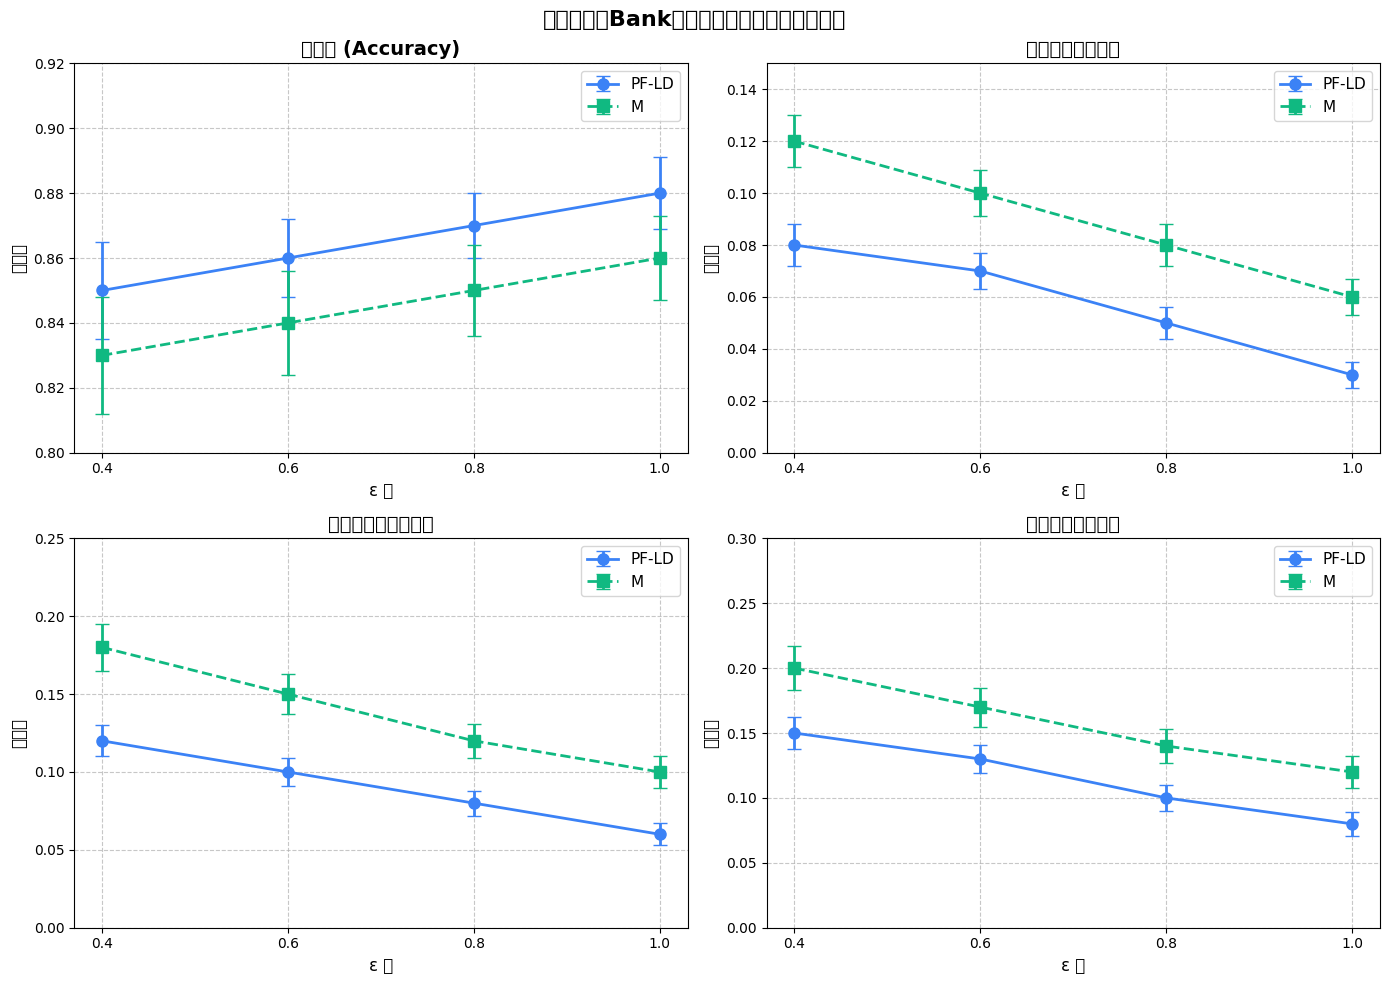

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# 设置中文显示
# plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
# plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 定义ε值范围
epsilon_values = np.array([0.4, 0.6, 0.8, 1.0])

# 模拟PF-LD方法在不同ε值下的各项指标结果（均值和标准差）
pf_ld_accuracy_mean = np.array([0.85, 0.86, 0.87, 0.88])
pf_ld_accuracy_std = np.array([0.015, 0.012, 0.01, 0.011])

pf_ld_accuracy_parity_mean = np.array([0.08, 0.07, 0.05, 0.03])
pf_ld_accuracy_parity_std = np.array([0.008, 0.007, 0.006, 0.005])

pf_ld_demographic_parity_mean = np.array([0.12, 0.10, 0.08, 0.06])
pf_ld_demographic_parity_std = np.array([0.01, 0.009, 0.008, 0.007])

pf_ld_equalized_odds_mean = np.array([0.15, 0.13, 0.10, 0.08])
pf_ld_equalized_odds_std = np.array([0.012, 0.011, 0.01, 0.009])

# 模拟M方法在不同ε值下的各项指标结果（均值和标准差）
m_accuracy_mean = np.array([0.83, 0.84, 0.85, 0.86])
m_accuracy_std = np.array([0.018, 0.016, 0.014, 0.013])

m_accuracy_parity_mean = np.array([0.12, 0.10, 0.08, 0.06])
m_accuracy_parity_std = np.array([0.01, 0.009, 0.008, 0.007])

m_demographic_parity_mean = np.array([0.18, 0.15, 0.12, 0.10])
m_demographic_parity_std = np.array([0.015, 0.013, 0.011, 0.01])

m_equalized_odds_mean = np.array([0.20, 0.17, 0.14, 0.12])
m_equalized_odds_std = np.array([0.017, 0.015, 0.013, 0.012])

# 创建一个包含2x2子图的图形
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# 绘制准确率图表
ax1 = axes[0, 0]
ax1.errorbar(epsilon_values, pf_ld_accuracy_mean, yerr=pf_ld_accuracy_std, 
             fmt='o-', color='#3B82F6', linewidth=2, markersize=8, capsize=5, label='PF-LD')
ax1.errorbar(epsilon_values, m_accuracy_mean, yerr=m_accuracy_std, 
             fmt='s--', color='#10B981', linewidth=2, markersize=8, capsize=5, label='M')
ax1.set_xlabel('ε 值', fontsize=12)
ax1.set_ylabel('准确率', fontsize=12)
ax1.set_title('准确率 (Accuracy)', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=11)
ax1.set_ylim(0.8, 0.92)  # 设置y轴范围

# 绘制准确率公平性偏差图表
ax2 = axes[0, 1]
ax2.errorbar(epsilon_values, pf_ld_accuracy_parity_mean, yerr=pf_ld_accuracy_parity_std, 
             fmt='o-', color='#3B82F6', linewidth=2, markersize=8, capsize=5, label='PF-LD')
ax2.errorbar(epsilon_values, m_accuracy_parity_mean, yerr=m_accuracy_parity_std, 
             fmt='s--', color='#10B981', linewidth=2, markersize=8, capsize=5, label='M')
ax2.set_xlabel('ε 值', fontsize=12)
ax2.set_ylabel('偏差值', fontsize=12)
ax2.set_title('准确率公平性偏差', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 0.15)  # 设置y轴范围

# 绘制人口统计公平性偏差图表
ax3 = axes[1, 0]
ax3.errorbar(epsilon_values, pf_ld_demographic_parity_mean, yerr=pf_ld_demographic_parity_std, 
             fmt='o-', color='#3B82F6', linewidth=2, markersize=8, capsize=5, label='PF-LD')
ax3.errorbar(epsilon_values, m_demographic_parity_mean, yerr=m_demographic_parity_std, 
             fmt='s--', color='#10B981', linewidth=2, markersize=8, capsize=5, label='M')
ax3.set_xlabel('ε 值', fontsize=12)
ax3.set_ylabel('偏差值', fontsize=12)
ax3.set_title('人口统计公平性偏差', fontsize=14, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(fontsize=11)
ax3.set_ylim(0, 0.25)  # 设置y轴范围

# 绘制等赔率公平性偏差图表
ax4 = axes[1, 1]
ax4.errorbar(epsilon_values, pf_ld_equalized_odds_mean, yerr=pf_ld_equalized_odds_std, 
             fmt='o-', color='#3B82F6', linewidth=2, markersize=8, capsize=5, label='PF-LD')
ax4.errorbar(epsilon_values, m_equalized_odds_mean, yerr=m_equalized_odds_std, 
             fmt='s--', color='#10B981', linewidth=2, markersize=8, capsize=5, label='M')
ax4.set_xlabel('ε 值', fontsize=12)
ax4.set_ylabel('偏差值', fontsize=12)
ax4.set_title('等赔率公平性偏差', fontsize=14, fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(fontsize=11)
ax4.set_ylim(0, 0.3)  # 设置y轴范围

# 统一设置x轴刻度
for ax in axes.flat:
    ax.set_xticks(epsilon_values)

# 添加整体标题
fig.suptitle('不同方法在Bank数据集上的性能与公平性对比', fontsize=16, fontweight='bold', y=0.98)

# 调整布局并保存图像
plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def plot_results(epsilons, results_fair, results_no_fair, num_rounds):
    """
    Plot the accuracy and fairness metrics for different epsilons
    """
    # Create a figure with two subplots: accuracy and fairness
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy for different epsilons
    colors = ['b', 'g', 'r', 'c', 'm']
    for i, epsilon in enumerate(epsilons):
        # Smooth the accuracy curve (optional)
        smooth_accuracy_fair = pd.Series(results_fair[epsilon]['accuracy']).rolling(window=2, min_periods=1).mean()
        smooth_accuracy_no_fair = pd.Series(results_no_fair[epsilon]['accuracy']).rolling(window=2, min_periods=1).mean()
        
        ax1.plot(range(1, num_rounds+1), smooth_accuracy_no_fair, color=colors[i], linestyle='-', marker='o', 
                 label=f'No Fairness ($\epsilon$={epsilon})',linewidth=3, markersize=15)
        ax1.plot(range(1, num_rounds+1), smooth_accuracy_fair, color=colors[i], linestyle='--', marker='s', 
                 label=f'With Fairness ($\epsilon$={epsilon})',linewidth=3, markersize=15)
    
    ax1.set_title('Accuracy vs Training Rounds for Different Privacy Budgets', fontsize=20)
    ax1.set_xlabel('Training Rounds', fontsize=20)
    ax1.set_ylabel('Accuracy', fontsize=20)
    # ax1.xticks(fontsize=20)
    # ax1.yticks(fontsize=20)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot fairness metric (Discrimination) for different epsilons
    for i, epsilon in enumerate(epsilons):
        # Smooth the fairness curve (optional)
        smooth_fairness_fair = pd.Series(results_fair[epsilon]['eq_odds_diff']).rolling(window=2, min_periods=1).mean()
        smooth_fairness_no_fair = pd.Series(results_no_fair[epsilon]['eq_odds_diff']).rolling(window=2, min_periods=1).mean()
        
        ax2.plot(range(1, num_rounds+1), smooth_fairness_no_fair, color=colors[i], linestyle='-', marker='o', 
                 label=f'No Fairness ($\epsilon$={epsilon})')
        ax2.plot(range(1, num_rounds+1), smooth_fairness_fair, color=colors[i], linestyle='--', marker='s', 
                 label=f'With Fairness ($\epsilon$={epsilon})')
    
    ax2.set_title('Discrimination vs Training Rounds for Different Privacy Budgets', fontsize=20)
    ax2.set_xlabel('Training Rounds', fontsize=20)
    ax2.set_ylabel('Discrimination', fontsize=20)
    # ax2.xticks(fontsize=20)
    # ax2.yticks(fontsize=20)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig('privacy_fairness_utility.png', dpi=300)
    plt.show()